# 03 · Classification: exposure to the *Gas Guzzler Tax*

The U.S. *Gas Guzzler Tax* applies to **passenger cars** whose unadjusted combined fuel economy is below 22.5 mpg;
vehicles classified by NHTSA as trucks (large SUVs, pickups) are exempt.

**Business question:** can we anticipate whether a configuration will pay the tax **before certification**, i.e.
without knowing its fuel economy? This is a useful early signal for product line definition and planning.

## Protocol

| Element | Decision |
|---|---|
| Imbalance | 55 positives out of 964 (5.7 %) → **stratified** splits, positive-class metrics (precision, recall, F1, PR-AUC) |
| Leakage across variants | Splits **grouped by model family** (`StratifiedGroupKFold`) |
| Hyperparameter selection | Training data only, optimizing F1 |
| Stability | Repeated cross-validation (3 seeds × 5 folds) |
| Baselines | Majority class and an engine-based expert rule |

In [1]:
try:
    import vehicle_emissions  # installed with `pip install -e .`
except ModuleNotFoundError:  # running without installing the package
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
RANDOM_STATE = 42

In [2]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, average_precision_score,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from vehicle_emissions.data import load_fe_guide
from vehicle_emissions.paths import FIGURES_DIR
from vehicle_emissions.validation import validate_fe_guide

df = load_fe_guide()
validate_fe_guide(df)
print(df["Guzzler?"].value_counts().rename({0: "Not guzzler", 1: "Guzzler"}).to_string())

Guzzler?
Not guzzler    909
Guzzler         55


## 1. Problem structure

In [3]:
pd.crosstab(df["Gas Guzzler Exempt"].map({0: "Not exempt (car)", 1: "Exempt (NHTSA truck)"}),
            df["Guzzler?"].map({0: "Not guzzler", 1: "Guzzler"}), margins=True, margins_name="Total")

Guzzler?,Guzzler,Not guzzler,Total
Gas Guzzler Exempt,,,
Exempt (NHTSA truck),0,537,537
Not exempt (car),55,372,427
Total,55,909,964


In [4]:
pd.crosstab(df["# Cyl"], df["Guzzler?"].map({0: "Not guzzler", 1: "Guzzler"}))

Guzzler?,Guzzler,Not guzzler
# Cyl,,
3,0,25
4,0,436
5,0,1
6,12,308
8,24,139
10,3,0
12,15,0
16,1,0


Two rules follow directly from regulation and data: **no exempt vehicle pays** and **every engine with 10 or more
cylinders pays**. The difficulty lies in 6- and 8-cylinder passenger cars, which fall on both sides of the threshold.

## 2. Features and split

In [5]:
NUM = ["Eng Displ", "# Cyl", "# Gears", "Hybrid", "Gas Guzzler Exempt"]
CAT = ["Trans Desc", "Drive Desc", "Fuel Usage", "Carline Class Desc"]
X, y, groups = df[NUM + CAT], df["Guzzler?"], df["Model Family"]

outer = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
idx_tr, idx_te = next(outer.split(X, y, groups))
X_train, X_test, y_train, y_test = X.iloc[idx_tr], X.iloc[idx_te], y.iloc[idx_tr], y.iloc[idx_te]
g_train = groups.iloc[idx_tr]
assert not set(g_train) & set(groups.iloc[idx_te]), "model families leak between train and test"
print(f"Training: {len(X_train)} ({y_train.sum()} guzzlers) · Test: {len(X_test)} ({y_test.sum()} guzzlers)")
inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def metrics(name, y_true, y_pred, y_score=None):
    return {"Model": name,
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred), "F1": f1_score(y_true, y_pred),
            "PR-AUC": average_precision_score(y_true, y_score) if y_score is not None else np.nan}
holdout = []

Training: 644 (37 guzzlers) · Test: 320 (18 guzzlers)


## 3. Baselines

* **Majority class:** always predicts "not guzzler" (94 % accuracy, zero usefulness).
* **Expert rule:** non-exempt passenger car with 8 or more cylinders. This is what an engineer would apply without a model.

In [6]:
class ExpertRule(BaseEstimator, ClassifierMixin):
    """Guzzler if the vehicle is not exempt and has at least `min_cyl` cylinders."""

    def __init__(self, min_cyl=8):
        self.min_cyl = min_cyl

    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        return ((X["Gas Guzzler Exempt"] == 0) & (X["# Cyl"] >= self.min_cyl)).astype(int).to_numpy()

    def predict_proba(self, X):
        p = self.predict(X)
        return np.c_[1 - p, p]

for name, est in [("Baseline · majority class", DummyClassifier(strategy="most_frequent")),
                  ("Baseline · expert rule (≥ 8 cyl., not exempt)", ExpertRule())]:
    est.fit(X_train, y_train)
    holdout.append(metrics(name, y_test, est.predict(X_test), est.predict_proba(X_test)[:, 1]))
pd.DataFrame(holdout).set_index("Model").round(3)

,Precision,Recall,F1,PR-AUC
Model,,,,
Baseline · majority class,0.000,0.000,0.0,0.056
"Baseline · expert rule (≥ 8 cyl., not exempt)",0.636,0.778,0.7,0.507


## 4. Logistic regression (class-weighted linear model)

In [7]:
pre_scaled = ColumnTransformer([("num", StandardScaler(), NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])
logit = GridSearchCV(Pipeline([("pre", pre_scaled), ("clf", LogisticRegression(class_weight="balanced", max_iter=5000))]),
                     {"clf__C": [0.01, 0.1, 1, 10]}, cv=inner, scoring="f1")
logit.fit(X_train, y_train, groups=g_train)
best_logit = logit.best_estimator_
print("C =", logit.best_params_["clf__C"])
holdout.append(metrics("Logistic regression", y_test, best_logit.predict(X_test), best_logit.predict_proba(X_test)[:, 1]))

C = 10


## 5. Decision tree

In [8]:
pre_tree = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), CAT)], remainder="passthrough")
tree_search = GridSearchCV(
    Pipeline([("pre", pre_tree), ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    {"clf__max_depth": [2, 3, 4, 5, 8, None], "clf__min_samples_leaf": [1, 2, 4, 8],
     "clf__criterion": ["gini", "entropy"], "clf__class_weight": [None, "balanced"]},
    cv=inner, scoring="f1", n_jobs=-1)
tree_search.fit(X_train, y_train, groups=g_train)
best_tree = tree_search.best_estimator_
print("Hyperparameters:", {k.split("__")[1]: v for k, v in tree_search.best_params_.items()})
holdout.append(metrics("Decision tree", y_test, best_tree.predict(X_test), best_tree.predict_proba(X_test)[:, 1]))

Hyperparameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2}


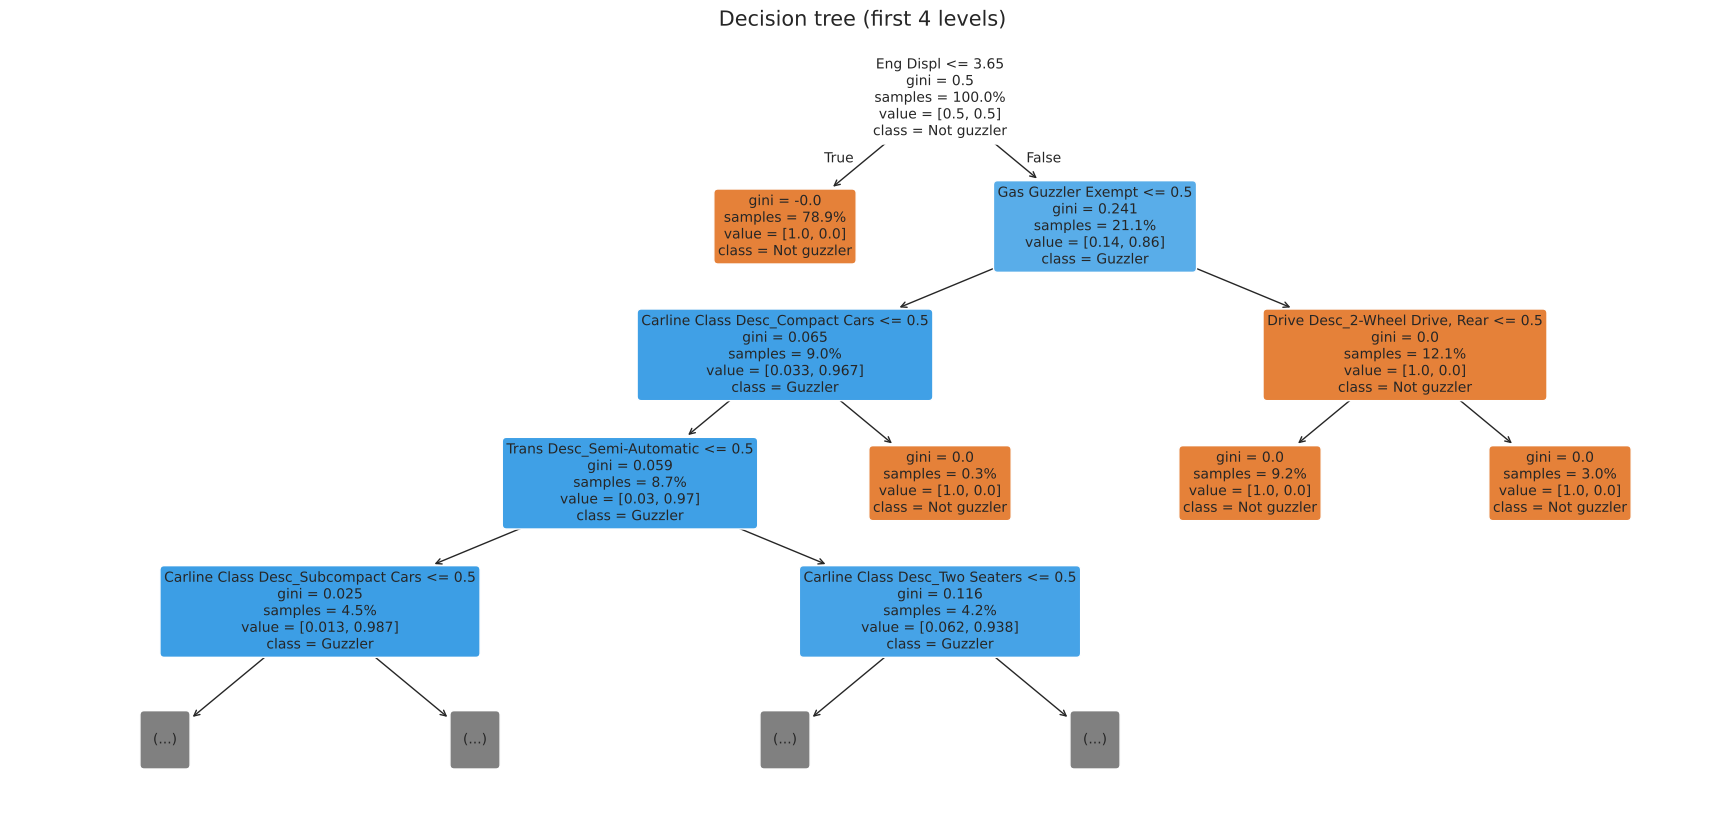

In [9]:
feature_names = [n.split("__", 1)[1] for n in best_tree.named_steps["pre"].get_feature_names_out()]
clf = best_tree.named_steps["clf"]
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(clf, feature_names=feature_names, class_names=["Not guzzler", "Guzzler"], filled=True, rounded=True,
          fontsize=10, max_depth=4, proportion=True, ax=ax)
ax.set_title("Decision tree (first 4 levels)", fontsize=15)
fig.savefig(FIGURES_DIR / "03_decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Neural network (multilayer perceptron)

In [10]:
mlp_search = GridSearchCV(
    Pipeline([("pre", pre_scaled), ("clf", MLPClassifier(activation="relu", solver="adam", max_iter=2000,
                                                          random_state=RANDOM_STATE))]),
    {"clf__hidden_layer_sizes": [(32,), (64, 32), (128, 64, 32, 16)], "clf__alpha": [1e-4, 1e-2, 1e-1]},
    cv=inner, scoring="f1", n_jobs=-1)
mlp_search.fit(X_train, y_train, groups=g_train)
best_mlp = mlp_search.best_estimator_
print("Hyperparameters:", {k.split("__")[1]: v for k, v in mlp_search.best_params_.items()})
holdout.append(metrics("Neural network (MLP)", y_test, best_mlp.predict(X_test), best_mlp.predict_proba(X_test)[:, 1]))

Hyperparameters: {'alpha': 0.01, 'hidden_layer_sizes': (128, 64, 32, 16)}


## 7. Hold-out results

In [11]:
res = pd.DataFrame(holdout).set_index("Model").round(3)
res

,Precision,Recall,F1,PR-AUC
Model,,,,
Baseline · majority class,0.000,0.000,0.000,0.056
"Baseline · expert rule (≥ 8 cyl., not exempt)",0.636,0.778,0.700,0.507
Logistic regression,0.552,0.889,0.681,0.816
Decision tree,0.667,0.889,0.762,0.582
Neural network (MLP),0.750,0.833,0.789,0.849


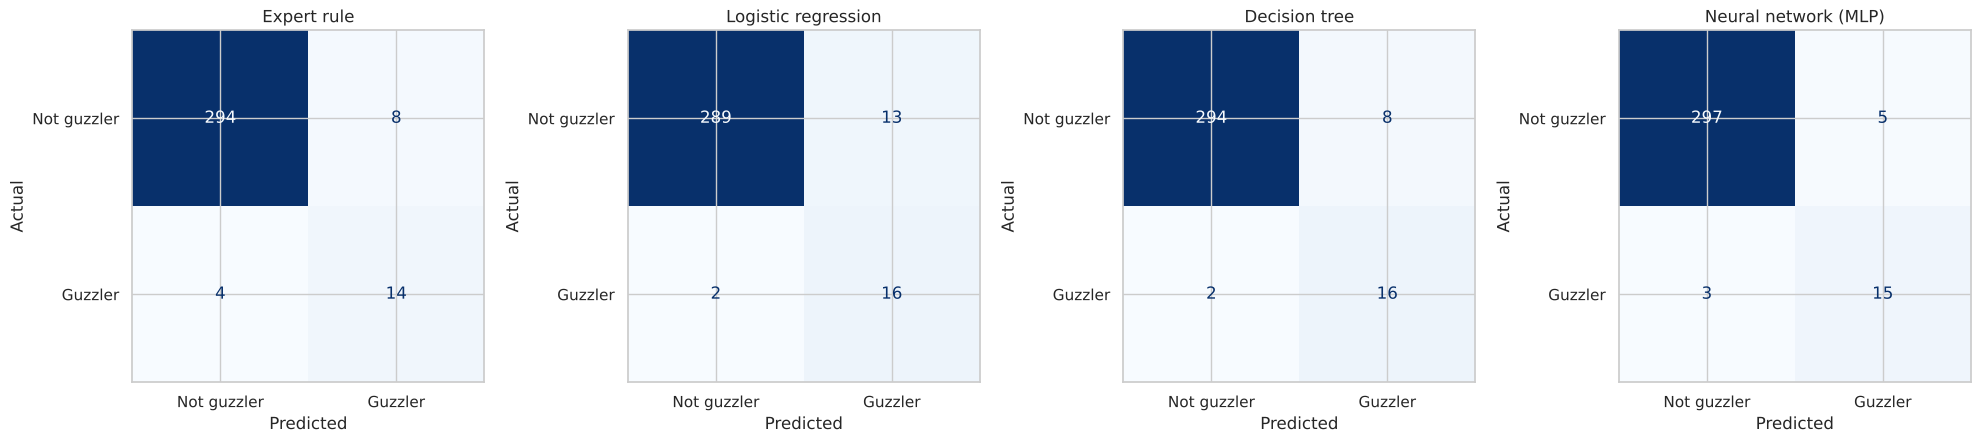

In [12]:
models = {"Expert rule": ExpertRule(), "Logistic regression": best_logit, "Decision tree": best_tree,
          "Neural network (MLP)": best_mlp}
fig, axs = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, m) in zip(axs, models.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, m.predict(X_test), display_labels=["Not guzzler", "Guzzler"],
                                            cmap="Blues", ax=ax, colorbar=False)
    ax.set(title=name, xlabel="Predicted", ylabel="Actual")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "03_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

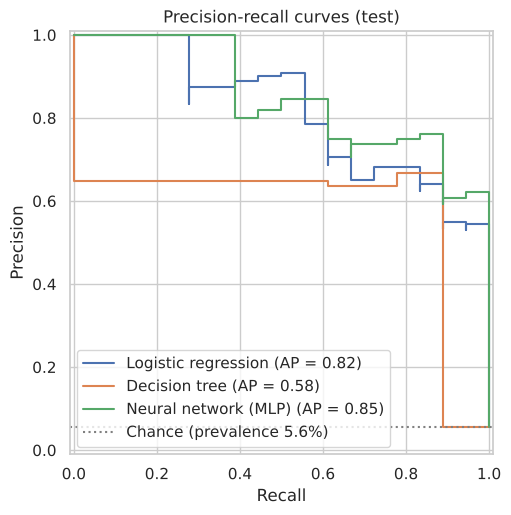

In [13]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for name, m in list(models.items())[1:]:
    PrecisionRecallDisplay.from_predictions(y_test, m.predict_proba(X_test)[:, 1], name=name, ax=ax)
ax.axhline(y_test.mean(), color="grey", ls=":", label=f"Chance (prevalence {y_test.mean():.1%})")
ax.set(title="Precision-recall curves (test)", xlabel="Recall", ylabel="Precision"); ax.legend(loc="lower left")
fig.savefig(FIGURES_DIR / "03_precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Stability: repeated cross-validation

With few positives in the test split, a single hold-out is noisy. A stratified, grouped 5-fold cross-validation is
repeated with 3 seeds, refitting each model with its selected hyperparameters.

In [14]:
rows = []
for name, m in models.items():
    # the expert rule yields no continuous scores, so its PR-AUC is not meaningful
    keys = ["F1", "Precision", "Recall"] + ([] if isinstance(m, ExpertRule) else ["PR-AUC"])
    sc = {"F1": "f1", "Precision": "precision", "Recall": "recall", "PR-AUC": "average_precision"}
    scores = {k: [] for k in keys}
    for seed in (0, 1, 2):
        cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        s = cross_validate(clone(m), X, y, groups=groups, cv=cv, scoring={k: sc[k] for k in keys})
        for k in keys:
            scores[k].extend(s[f"test_{k}"])
    rows.append({"Model": name, **{f"{k} mean": np.mean(v) for k, v in scores.items()},
                 "F1 std": np.std(scores["F1"])})
cv_table = pd.DataFrame(rows).set_index("Model").round(3)
cv_table

,F1 mean,Precision mean,Recall mean,F1 std,PR-AUC mean
Model,,,,,
Expert rule,0.683,0.624,0.777,0.112,NaN
Logistic regression,0.698,0.576,0.908,0.088,0.836
Decision tree,0.773,0.663,0.953,0.106,0.726
Neural network (MLP),0.796,0.817,0.811,0.110,0.877


## 9. Error analysis

In [15]:
err = df.iloc[idx_te].assign(tree=best_tree.predict(X_test), mlp=best_mlp.predict(X_test))
err = err[(err["tree"] != err["Guzzler?"]) | (err["mlp"] != err["Guzzler?"])]
print(f"Vehicles misclassified by at least one model: {len(err)} · "
      f"with unadjusted fuel economy between 19 and 26 mpg: {err['Comb Unadj FE'].between(19, 26).mean():.0%}")
err[["Division", "Carline", "Eng Displ", "# Cyl", "Carline Class Desc", "Comb Unadj FE", "Guzzler?", "tree", "mlp"]
    ].sort_values("Comb Unadj FE")

Vehicles misclassified by at least one model: 14 · with unadjusted fuel economy between 19 and 26 mpg: 64%


,Division,Carline,Eng Displ,# Cyl,Carline Class Desc,Comb Unadj FE,Guzzler?,tree,mlp
7,Chevrolet,CORVETTE Z06 CARBON AERO,5.5,8,Two Seaters,16.9373,1,0,1
6,Chevrolet,CORVETTE Z06,5.5,8,Two Seaters,17.8005,1,0,1
392,MASERATI,Quattroporte Trofeo,3.8,8,Large Cars,20.1400,1,1,0
317,MASERATI,Ghibli Trofeo,3.8,8,Midsize Cars,20.1400,1,1,0
262,Audi,RS 7,4.0,8,Midsize Cars,21.1994,1,1,0
51,Aston Martin Lagonda Ltd,DB12 V8,4.0,8,Minicompact Cars,22.4729,0,1,0
365,Audi,S8,4.0,8,Large Cars,23.5599,0,1,0
150,LEXUS,LC 500,5.0,8,Subcompact Cars,23.8549,0,1,0
4,Chevrolet,CORVETTE,6.2,8,Two Seaters,23.9592,0,0,1
37,Porsche,718 Cayman GTS 4.0,4.0,6,Two Seaters,25.0826,0,1,1


## 10. Conclusions

* **The problem is almost a regulatory rule.** A trivial expert rule (non-exempt car with ≥ 8 cylinders) already
  reaches F1 ≈ 0.68 in cross-validation; any model must be justified against it, not against accuracy.
* **The neural network is the best classifier** (F1 ≈ 0.80 and PR-AUC ≈ 0.88 in repeated CV), with the best balance
  between precision and recall. The **decision tree** favors recall (≈ 0.95): it misses almost no guzzlers at the cost
  of more false alarms, and in exchange it is fully auditable.
* **Variability across splits is high** (F1 std ≈ 0.1) because there are only 55 positives. Differences of a few
  hundredths between models are not significant; the robust conclusion is *model > expert rule > nothing*.
* **Errors concentrate at the regulatory boundary:** about two thirds of misclassified vehicles have an unadjusted
  fuel economy between 19 and 26 mpg, around the 22.5 mpg threshold. Without fuel economy, the engine configuration
  alone cannot resolve that band; this is the natural limit of an early signal.
* **Recommended use:** the tree as a high-recall screening filter during product definition, and the MLP as a
  probability estimate to prioritize which configurations to validate first on the test bench.